              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%

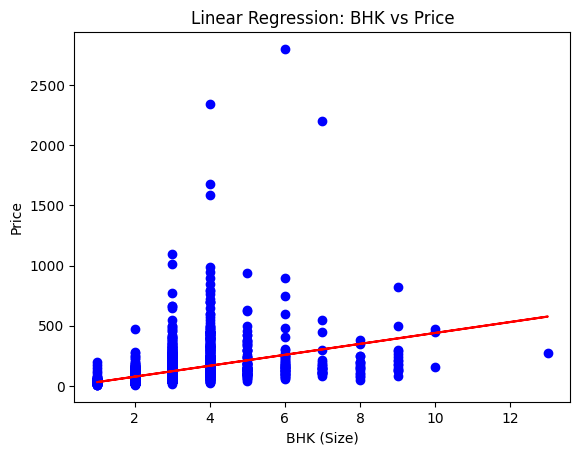

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load Excel file
data = pd.read_csv("bengaluru_house_prices.csv")

print(data.head())
print(data.describe())
print(data.info())
print(data.isnull().sum())

# Extract BHK count from 'size'
data['bhk'] = data['size'].str.extract(r'(\d+)').astype(float)

# Drop rows with missing values
data = data.dropna(subset=['bhk', 'price'])

X_single = data[['bhk']]
y = data['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_single, y, test_size=0.2, random_state=42)

model_s = LinearRegression()
model_s.fit(X_train_s, y_train_s)

y_pred_s = model_s.predict(X_test_s)



# Evaluation
print("MSE:", mean_squared_error(y_test_s, y_pred_s))
print("R2 Score:", r2_score(y_test_s, y_pred_s))

plt.figure()

# Scatter plot of actual data
plt.scatter(X_test_s, y_test_s, color='blue')
plt.plot(X_test_s, y_pred_s, color='red')
plt.xlabel("BHK (Size)")
plt.ylabel("Price")
plt.title("Linear Regression: BHK vs Price")
plt.show()


plt.show()